In [27]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd

In [28]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [29]:
X.shape

(1000, 2)

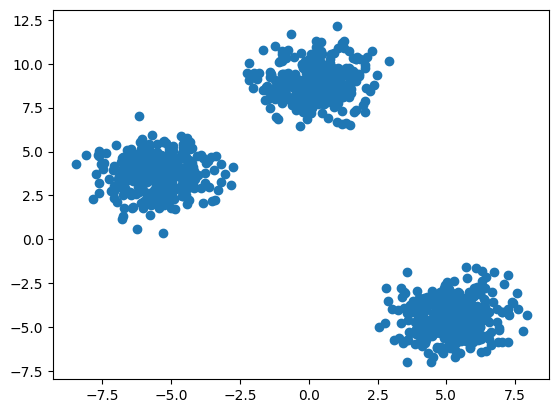

In [30]:
plt.scatter(X[:,0],X[:,1])

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
     X,y, test_size=0.33, random_state=42
)

In [32]:
from sklearn.cluster import KMeans

In [33]:
# manual process
# Elbow method to select k value

wcss= []
for k in range(1,11):
     kmeans = KMeans(n_clusters=k, init="k-means++")
     kmeans.fit(X_train)
     wcss.append(kmeans.inertia_)

In [34]:
wcss

[34827.57682552021,
 7935.437286145418,
 1319.2730531585612,
 1181.274184136212,
 992.5462587554139,
 893.063312091628,
 765.0424306954579,
 670.0740241829509,
 625.8903546899644,
 544.7693104144213]

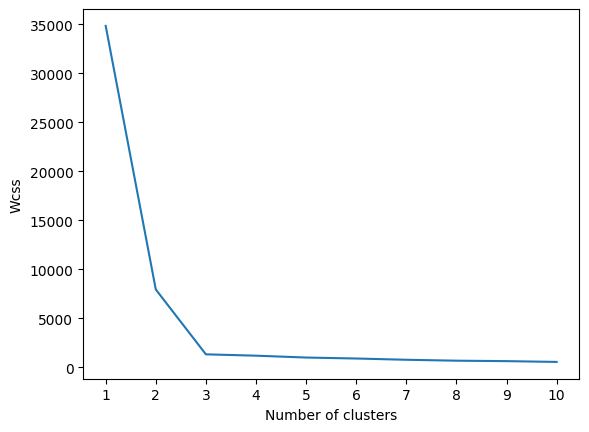

In [35]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("Wcss")
plt.show()

In [36]:
kmeans = KMeans(n_clusters=3,init="k-means++")
y_label=kmeans.fit_predict(X_train)

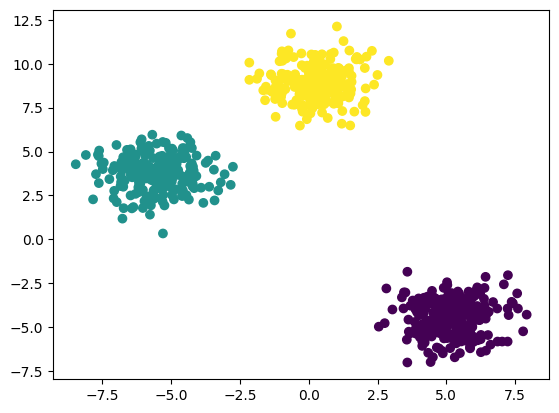

In [37]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_label)

In [38]:
y_test_label=kmeans.fit_predict(X_test)

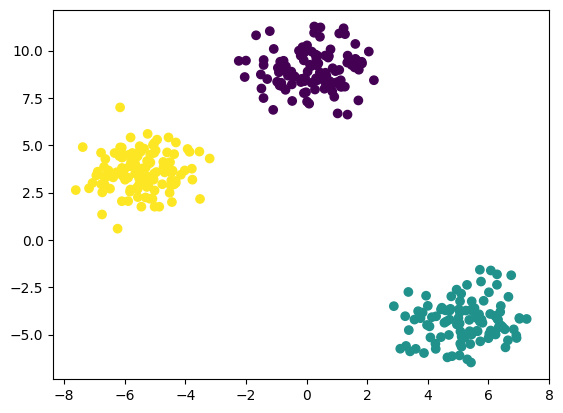

In [39]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

In [40]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [41]:
from sklearn.metrics import silhouette_score
Silhouette = []
for k in range(2,11):
     kmeans = KMeans(n_clusters=k, init="k-means++")
     kmeans.fit(X_train)
     Score = silhouette_score(X_train,kmeans.labels_)
     Silhouette.append(Score)


In [42]:
Silhouette

[0.7281443868598331,
 0.8071181203797672,
 0.6388220746591106,
 0.6321406154444159,
 0.45942572834625106,
 0.32959168432322816,
 0.3492525003826091,
 0.3267237922681396,
 0.33898565671219316]

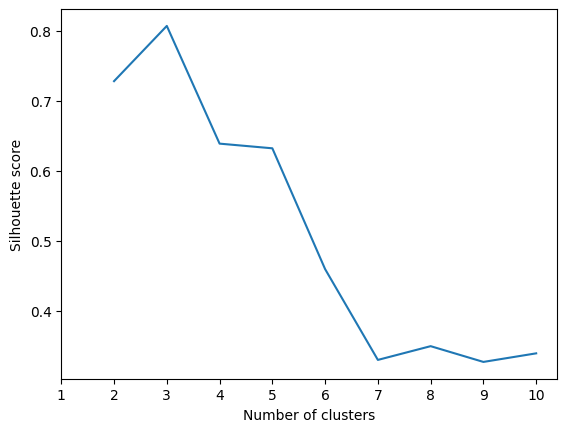

In [43]:
plt.plot(range(2,11), Silhouette)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()